In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#list the files in the drive
!ls '/content/drive/My Drive'

'274518_yalini.b_10th mark sheet.pdf'
 canada_per_capita_income.csv
 carprices.csv
'Colab Notebooks'
'Copy of house_price_dataset.xlsx'
 hiring.csv
 homeprices.jpg
 house_price_dataset.xlsx
 HR_comma_sep.csv
 IMG-20250603-WA0016.jpg
 loan_dataset
 moviegenre
 multimodal_pdf_chatbot_presentation.pptx
'New project'
'PDF Chatbot - Google Chrome 2026-01-05 06-18-31.mp4'
'Problem Statemen1.docx'
'Problem Statement_1.docx'
 python_functions.json
 Resume-2317034.pdf
 spamdetection
'Untitled document.gdoc'
'Untitled presentation.gslides'
'WhatsApp Image 2025-05-12 at 22.21.04_e90c1a3b.pdf'
'WhatsApp Image 2025-05-12 at 22.21 (1).04_e90c1a3b.pdf'
'WhatsApp Image 2025-05-12 at 22.21 (2).04_e90c1a3b.pdf'
 yalinib-714023243167.pdf
 yalini_mark.jpg


In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/My Drive/HR_comma_sep.csv')
df

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [ ]:
df.isnull().sum()

,0
satisfaction_level,0
last_evaluation,0
number_project,0
average_montly_hours,0
time_spend_company,0
Work_accident,0
left,0
promotion_last_5years,0
Department,0
salary,0


In [ ]:
(df == ' ').sum()

,0
satisfaction_level,0
last_evaluation,0
number_project,0
average_montly_hours,0
time_spend_company,0
Work_accident,0
left,0
promotion_last_5years,0
Department,0
salary,0


In [ ]:
for col in df.columns:
    if df[col].dtype == 'object':
      print(df[col].value_counts())


Department
sales          4140
technical      2720
support        2229
IT             1227
product_mng     902
marketing       858
RandD           787
accounting      767
hr              739
management      630
Name: count, dtype: int64
salary
low       7316
medium    6446
high      1237
Name: count, dtype: int64


In [ ]:
df.shape

(14999, 10)

In [ ]:
#split the numeric columns
num_col = df.select_dtypes(include=['int64','float64']).columns
print(num_col)

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years'],
      dtype='object')


In [ ]:
cat_col = df.select_dtypes(include=['object']).columns
cat_col

Index(['Department', 'salary'], dtype='object')

In [ ]:
new = num_col.drop(['Work_accident', 'left', 'promotion_last_5years'])
print(new)

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company'],
      dtype='object')


In [ ]:
cor = df[new].corr()
print(cor)

                      satisfaction_level  last_evaluation  number_project  \
satisfaction_level              1.000000         0.105021       -0.142970   
last_evaluation                 0.105021         1.000000        0.349333   
number_project                 -0.142970         0.349333        1.000000   
average_montly_hours           -0.020048         0.339742        0.417211   
time_spend_company             -0.100866         0.131591        0.196786   

                      average_montly_hours  time_spend_company  
satisfaction_level               -0.020048           -0.100866  
last_evaluation                   0.339742            0.131591  
number_project                    0.417211            0.196786  
average_montly_hours              1.000000            0.127755  
time_spend_company                0.127755            1.000000  


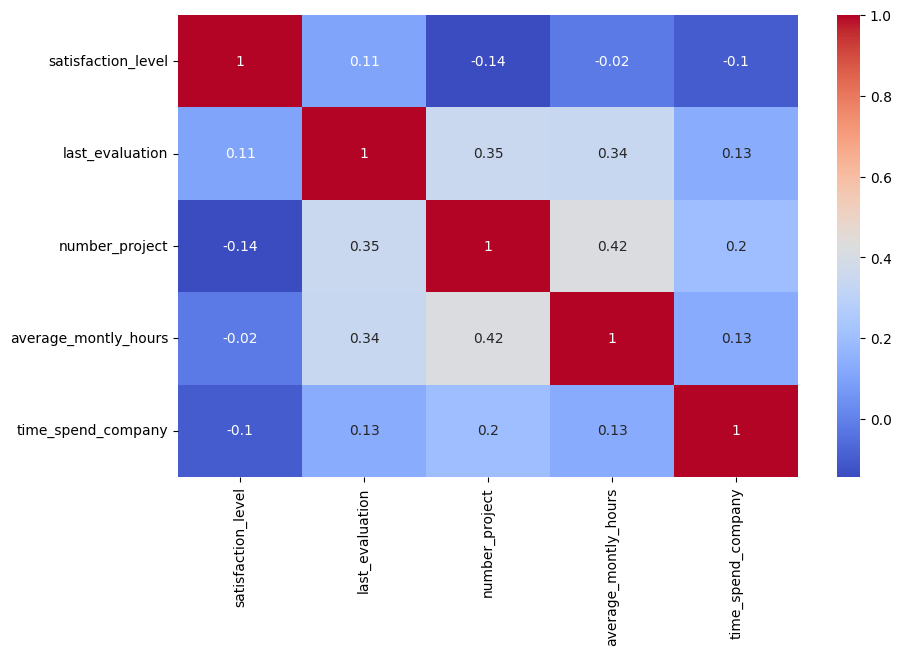

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
sns.heatmap(df[new].corr(),
annot=True,
cmap='coolwarm')
plt.show()


In [ ]:
df[num_col].corr()['left']

,left
satisfaction_level,-0.388375
last_evaluation,0.006567
number_project,0.023787
average_montly_hours,0.071287
time_spend_company,0.144822
Work_accident,-0.154622
left,1.000000
promotion_last_5years,-0.061788


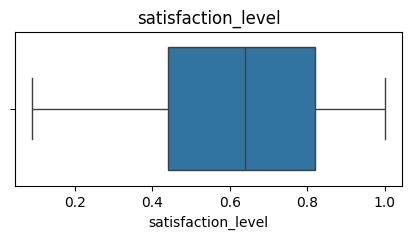

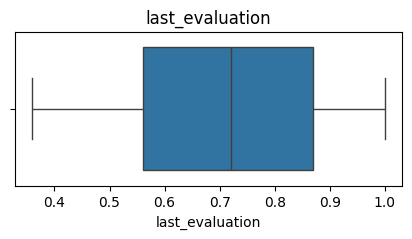

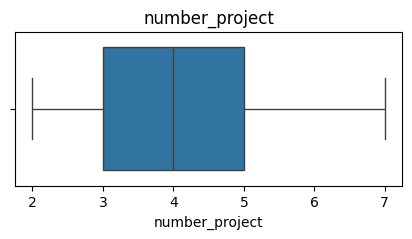

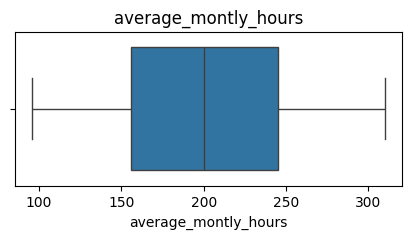

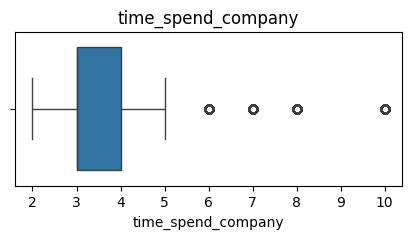

In [ ]:
for cols in new:
  plt.figure(figsize=(5,2))
  sns.boxplot(x=df[cols])
  plt.title(cols)
  plt.show()

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
ct = ColumnTransformer([('encoder', OneHotEncoder(), cat_col)],remainder='passthrough')
x = df.drop('left',axis=1)
y = df['left']
x = ct.fit_transform(x)
x

array([[0., 0., 0., ..., 3., 0., 0.],
       [0., 0., 0., ..., 6., 0., 0.],
       [0., 0., 0., ..., 4., 0., 0.],
       ...,
       [0., 0., 0., ..., 3., 0., 0.],
       [0., 0., 0., ..., 4., 0., 0.],
       [0., 0., 0., ..., 3., 0., 0.]])

In [ ]:
y

,left
0,1
1,1
2,1
3,1
4,1
...,...
14994,1
14995,1
14996,1
14997,1


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)


In [ ]:
x_train

array([[0., 0., 0., ..., 4., 0., 0.],
       [0., 0., 0., ..., 5., 0., 0.],
       [0., 1., 0., ..., 2., 0., 0.],
       ...,
       [0., 0., 0., ..., 2., 0., 0.],
       [0., 0., 0., ..., 5., 0., 0.],
       [0., 0., 0., ..., 4., 0., 0.]])

In [ ]:
x_test

array([[0., 0., 0., ..., 2., 1., 0.],
       [1., 0., 0., ..., 2., 0., 0.],
       [0., 0., 0., ..., 2., 0., 0.],
       ...,
       [0., 0., 0., ..., 3., 0., 0.],
       [0., 0., 0., ..., 2., 0., 0.],
       [0., 0., 0., ..., 5., 0., 0.]])

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [ ]:
x_train

array([[-0.29756031, -0.23342308, -0.23579555, ...,  0.34061666,
        -0.41100307, -0.14998935],
       [-0.29756031, -0.23342308, -0.23579555, ...,  1.02407141,
        -0.41100307, -0.14998935],
       [-0.29756031,  4.2840665 , -0.23579555, ..., -1.02629282,
        -0.41100307, -0.14998935],
       ...,
       [-0.29756031, -0.23342308, -0.23579555, ..., -1.02629282,
        -0.41100307, -0.14998935],
       [-0.29756031, -0.23342308, -0.23579555, ...,  1.02407141,
        -0.41100307, -0.14998935],
       [-0.29756031, -0.23342308, -0.23579555, ...,  0.34061666,
        -0.41100307, -0.14998935]])

In [ ]:
x_test

array([[-0.29756031, -0.23342308, -0.23579555, ..., -1.02629282,
         2.43307183, -0.14998935],
       [ 3.36066323, -0.23342308, -0.23579555, ..., -1.02629282,
        -0.41100307, -0.14998935],
       [-0.29756031, -0.23342308, -0.23579555, ..., -1.02629282,
        -0.41100307, -0.14998935],
       ...,
       [-0.29756031, -0.23342308, -0.23579555, ..., -0.34283808,
        -0.41100307, -0.14998935],
       [-0.29756031, -0.23342308, -0.23579555, ..., -1.02629282,
        -0.41100307, -0.14998935],
       [-0.29756031, -0.23342308, -0.23579555, ...,  1.02407141,
        -0.41100307, -0.14998935]])

In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(class_weight='balanced')
lr.fit(x_train,y_train)

LogisticRegression(class_weight='balanced')

In [ ]:
y_pred = lr.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))


0.7643333333333333
[[1725  569]
 [ 138  568]]
              precision    recall  f1-score   support

           0       0.93      0.75      0.83      2294
           1       0.50      0.80      0.62       706

    accuracy                           0.76      3000
   macro avg       0.71      0.78      0.72      3000
weighted avg       0.83      0.76      0.78      3000



In [ ]:
pip install joblib

In [ ]:
import joblib
joblib.dump(lr,'employee.pkl')
joblib.dump(sc,'scaler.pkl')
joblib.dump(ct,'encoder.pkl')

['encoder.pkl']

In [ ]:
import pandas as pd

new_employee = pd.DataFrame({

    'satisfaction_level':[0.38],

    'last_evaluation':[0.53],

    'number_project':[2],

    'average_montly_hours':[157],

    'time_spend_company':[3],

    'Work_accident':[0],

    'promotion_last_5years':[0],

    'Department':['sales'],

    'salary':['low']
})

In [ ]:
new_data = ct.transform(new_employee)
new_data

array([[  0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   1.  ,
          0.  ,   0.  ,   0.  ,   1.  ,   0.  ,   0.38,   0.53,   2.  ,
        157.  ,   3.  ,   0.  ,   0.  ]])

In [ ]:
new_data = sc.transform(new_data)
new_data

array([[-0.29756031, -0.23342308, -0.23579555, -0.22578001, -0.21283823,
        -0.24299543, -0.25710689,  1.61784591, -0.41542618, -0.47026373,
        -0.29888581,  1.02660601, -0.87053873, -0.93478364, -1.08586587,
        -1.46377697, -0.88179673, -0.34283808, -0.41100307, -0.14998935]])

In [ ]:
prediction = lr.predict(new_data)

print(prediction)

[1]
